<a href="https://colab.research.google.com/github/Yurida26/UTS-NLP-SemanticSquad/blob/main/4_Evaluation_and_Deployment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Notebook ini mencakup:
1. **Model Evaluation:** Visualisasi Confusion Matrix dan Laporan Performa.
2. **Gradio Deployment:** Pembuatan antarmuka aplikasi untuk prediksi kategori produk.

Install & Load Library

In [2]:
# Install Gradio
!pip install gradio

import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Load Model dan Vectorizer
try:
    model = pickle.load(open('best_model_classifier.pkl', 'rb'))
    vectorizer = pickle.load(open('tfidf_vectorizer.pkl', 'rb'))
    print("Model dan Vectorizer berhasil dimuat dari folder lokal!")
except:
    print("Error: File .pkl tidak ditemukan. Silakan upload file 'best_model_classifier.pkl' dan 'tfidf_vectorizer.pkl'.")
# Mapping manual agar hasil prediksi keluar nama kategorinya, bukan angka
label_map = {
    0: 'Elektronik',
    1: 'Handphone & Tablet',
    2: 'Kesehatan',
    3: 'Makanan & Minuman',
    4: 'Olahraga',
    5: 'Pertukangan'
}

print("Model dan Vectorizer berhasil dimuat!")

Model dan Vectorizer berhasil dimuat dari folder lokal!
Model dan Vectorizer berhasil dimuat!


**EVALUATION**

Visualisasi Confusion Matrix

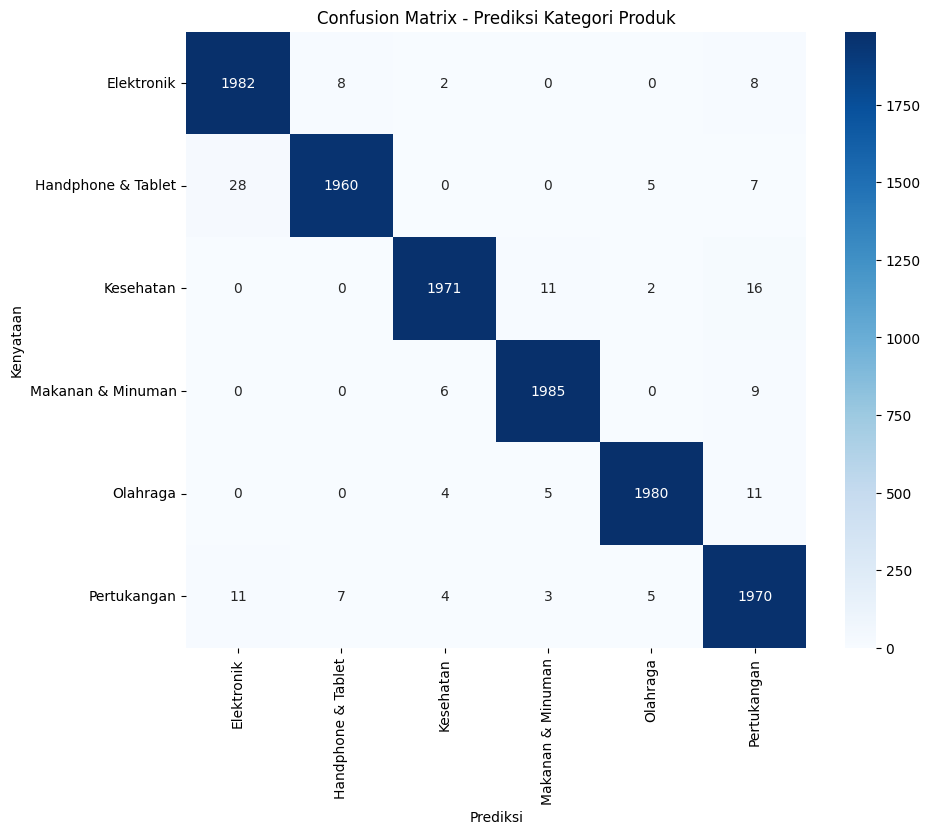


Laporan Klasifikasi:
                    precision    recall  f1-score   support

        Elektronik       0.98      0.99      0.99      2000
Handphone & Tablet       0.99      0.98      0.99      2000
         Kesehatan       0.99      0.99      0.99      2000
 Makanan & Minuman       0.99      0.99      0.99      2000
          Olahraga       0.99      0.99      0.99      2000
       Pertukangan       0.97      0.98      0.98      2000

          accuracy                           0.99     12000
         macro avg       0.99      0.99      0.99     12000
      weighted avg       0.99      0.99      0.99     12000



In [4]:
# Load data cleaned untuk evaluasi
try:
    df_eval = pd.read_csv('products_cleaned.csv').dropna()

    # Transformasi teks ke fitur TF-IDF
    X_eval = vectorizer.transform(df_eval['clean_text'])
    y_true = df_eval['category_label']

    # Prediksi
    y_pred = model.predict(X_eval)

    # Visualisasi Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_map.values(),
                yticklabels=label_map.values())
    plt.title('Confusion Matrix - Prediksi Kategori Produk')
    plt.xlabel('Prediksi')
    plt.ylabel('Kenyataan')
    plt.show()

    print("\nLaporan Klasifikasi:")
    print(classification_report(y_true, y_pred, target_names=label_map.values()))
except:
    print("Error: File 'products_cleaned.csv' tidak ditemukan untuk tahap evaluasi.")

**DEPLOYMENT**

Membuat Aplikasi dengan Gradio

In [5]:
import gradio as gr
import re

# Fungsi untuk membersihkan input user (harus sama dengan tahap preprocessing)
def clean_input(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Hapus karakter selain huruf
    return text

# Fungsi Prediksi Utama
def predict_category(product_review):
    # 1. Bersihkan teks input
    cleaned_text = clean_input(product_review)
    # 2. Transformasi ke angka pakai vectorizer
    text_vector = vectorizer.transform([cleaned_text])
    # 3. Prediksi pakai model
    prediction = model.predict(text_vector)[0]
    # 4. Ambil nama kategorinya
    return label_map[prediction]

# Membuat Interface Gradio
demo = gr.Interface(
    fn=predict_category,
    inputs=gr.Textbox(lines=3, placeholder="Masukkan nama produk atau ulasan di sini..."),
    outputs="text",
    title="📦 Product Category Classifier",
    description="Aplikasi ini akan menebak kategori produk berdasarkan ulasan atau nama produk yang Anda masukkan.",
    examples=[
        ["Botol minum stainless steel kapasitas 500ml"],
        ["Obat batuk herbal manjur sekali"],
        ["Rak piring kayu minimalis untuk dapur"]
    ]
)

# Jalankan Aplikasi
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://dfaa769cc210bf763d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
